KNN - K-Nearest Neighbours : to predict if a passenger survives, find the k most similar passanger in training data and take a majority vote. No training happens at all, it just memorizes the data and compares at prediction time. K = 3 means look at 3 nearest neighbours

Problem with KNN : slow on large data and sensitive to scale : Age (0 - 80) will overpower Sex (0 - 1) unless we normalize

In [14]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')
df.drop(columns = ['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace = True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male' : 0, 'female' : 1})
df = pd.get_dummies(df, columns = ['Embarked'], drop_first = True)

X = df.drop(columns = ['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Scale feature - KNN needs it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

display('ready')

'ready'

Standard Scaler: converts every feature to the same scale. (mean 0, standard deviation 1)

So now age (0-80) and sex (0-1) are now on equal footing

Note: fit_transform on train, only transform on test. Never fit on test data, that would be data leakage.

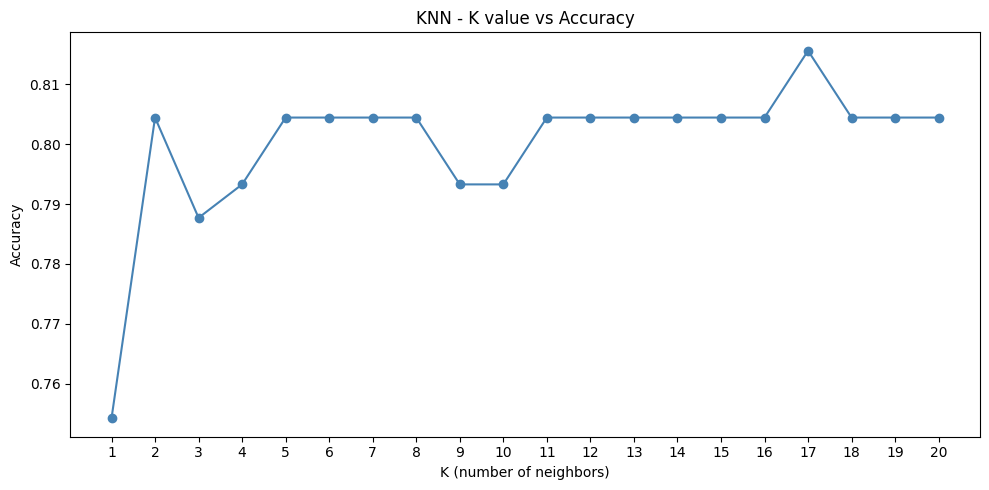

Best K: 17 with accuracy: 0.8156


In [25]:
# find the best K for KNN
# trying different values of K and record accuracy

k_scores = []
for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    k_scores.append(acc)

plt.figure(figsize = (10,5))
plt.plot(range(1,21), k_scores, marker = 'o', color = 'steelblue')
plt.title('KNN - K value vs Accuracy')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.tight_layout()
plt.savefig('KNN_K_Tuning.png', dpi = 150)
plt.show()

best_k = k_scores.index(max(k_scores)) + 1
print(f"Best K: {best_k} with accuracy: {max(k_scores):.4f}")